# Final Project Results Summary

This notebook provides a comprehensive summary of all experimental results across:
1. Traditional Machine Learning (9+ models, 4 feature selection methods)
2. Artificial Neural Network on handcrafted features
3. CNN Transfer Learning on raw images

**Output:**
- Comprehensive comparison tables
- Performance visualization plots
- Confusion matrices for best models
- Paradigm comparison (Traditional ML vs Deep Learning)
- Statistical analysis and insights

In [1]:
# Cell 1: Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Paths
PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'traditional_ml'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Results dir:', RESULTS_DIR)
print('Plots dir:', PLOTS_DIR)
print(f'\nFound {len(list(RESULTS_DIR.glob("result_*.json")))} result files')

Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
Results dir: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\traditional_ml
Plots dir: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots

Found 77 result files


In [2]:
# Cell 2: Load All Traditional ML + ANN Results
result_files = list(RESULTS_DIR.glob('result_*.json'))
print(f'Loading {len(result_files)} result files...\n')

results = []
for file in result_files:
    with open(file, 'r') as f:
        data = json.load(f)
        results.append(data)

print(f'Loaded {len(results)} results')
print('\nMethods found:', sorted(set(r['method'] for r in results)))
print('Models found:', sorted(set(r['model'] for r in results)))

Loading 77 result files...

Loaded 77 results

Methods found: ['fstat', 'mutual_info', 'pca', 'random_forest', 'raw']
Models found: ['dummy_most_frequent', 'gaussian_nb', 'knn_k7', 'linear_svm', 'linear_svm_balanced', 'logreg', 'logreg_balanced', 'mlp_ann', 'random_forest', 'rbf_svm']


In [21]:
# Cell 3: Build Comprehensive Results DataFrame
rows = []
for r in results:
    rows.append({
        'method': r['method'],
        'model': r['model'],
        'n_features': r['n_features'],
        'train_acc': r['train']['acc'],
        'train_f1_macro': r['train']['f1_macro'],
        'val_acc': r['val']['acc'],
        'val_f1_macro': r['val']['f1_macro'],
        'test_acc': r['test']['acc'],
        'test_f1_macro': r['test']['f1_macro'],
        'test_f1_weighted': r['test']['f1_weighted'],
    })

df_all = pd.DataFrame(rows)
df_all['overfit_gap'] = df_all['train_acc'] - df_all['test_acc']

# Sort by test F1-macro (best metric for imbalanced data)
df_sorted = df_all.sort_values(['test_f1_macro', 'test_acc'], ascending=False).reset_index(drop=True)

print('='*100)
print('COMPREHENSIVE RESULTS TABLE (sorted by Test F1-Macro)')
print('='*100)
print(df_sorted.to_string(index=False))
print('\n')
print(f'Total models evaluated: {len(df_all)}')
print(f'Best Test Accuracy: {df_all["test_acc"].max():.4f} ({df_sorted.iloc[0]["model"]}, {df_sorted.iloc[0]["method"]})')
print(f'Best Test F1-Macro: {df_all["test_f1_macro"].max():.4f} ({df_sorted.iloc[0]["model"]}, {df_sorted.iloc[0]["method"]})')

COMPREHENSIVE RESULTS TABLE (sorted by Test F1-Macro)
       method               model  n_features  train_acc  train_f1_macro  val_acc  val_f1_macro  test_acc  test_f1_macro  test_f1_weighted  overfit_gap
          pca              logreg        1058   0.999253        0.999691 0.684211      0.418163  0.683502       0.437570          0.666252     0.315751
          pca              logreg        1058   0.999253        0.999691 0.684211      0.418163  0.683502       0.437570          0.666252     0.315751
          pca              logreg        1058   0.999253        0.999691 0.684211      0.418163  0.683502       0.437570          0.666252     0.315751
          pca              logreg        1058   0.999842        0.999842 0.698246      0.434465  0.683502       0.432462          0.669896     0.316340
          pca     logreg_balanced        1058   0.999842        0.999842 0.698246      0.434465  0.683502       0.432462          0.669896     0.316340
          pca              logreg 

In [4]:
# Cell 4: Save Comprehensive Results Table
output_csv = RESULTS_DIR / 'final_comprehensive_results.csv'
df_sorted.to_csv(output_csv, index=False)
print(f'Saved comprehensive results to: {output_csv}')

# Also save top 10
top10_csv = RESULTS_DIR / 'top10_models.csv'
df_sorted.head(10).to_csv(top10_csv, index=False)
print(f'Saved top 10 models to: {top10_csv}')

Saved comprehensive results to: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\traditional_ml\final_comprehensive_results.csv
Saved top 10 models to: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\traditional_ml\top10_models.csv


In [5]:
# Cell 5: Extract Best Models per Method
print('BEST MODEL PER FEATURE SELECTION METHOD')
print('='*80)

best_per_method = df_all.loc[df_all.groupby('method')['test_f1_macro'].idxmax()]
best_per_method = best_per_method.sort_values('test_f1_macro', ascending=False)

for idx, row in best_per_method.iterrows():
    print(f"\n{row['method'].upper()} ({row['n_features']} features):")
    print(f"  Best Model: {row['model']}")
    print(f"  Test Acc: {row['test_acc']:.4f} | Test F1-Macro: {row['test_f1_macro']:.4f}")
    print(f"  Training Time: {row['fit_time_s']:.2f}s | Overfit Gap: {row['overfit_gap']:.4f}")

BEST MODEL PER FEATURE SELECTION METHOD

PCA (1058 features):
  Best Model: logreg
  Test Acc: 0.6835 | Test F1-Macro: 0.4376
  Training Time: 32.10s | Overfit Gap: 0.3158

RANDOM_FOREST (100 features):
  Best Model: gaussian_nb
  Test Acc: 0.5084 | Test F1-Macro: 0.2763
  Training Time: 0.00s | Overfit Gap: 0.0663

MUTUAL_INFO (100 features):
  Best Model: rbf_svm
  Test Acc: 0.5690 | Test F1-Macro: 0.2719
  Training Time: 0.09s | Overfit Gap: 0.4302

FSTAT (100 features):
  Best Model: gaussian_nb
  Test Acc: 0.4175 | Test F1-Macro: 0.2149
  Training Time: 0.00s | Overfit Gap: 0.0317

RAW (26543 features):
  Best Model: dummy_most_frequent
  Test Acc: 0.4074 | Test F1-Macro: 0.0482
  Training Time: 0.00s | Overfit Gap: -0.0135


In [6]:
# Cell 6: Filter PCA Results for Detailed Analysis
df_pca = df_all[df_all['method'] == 'pca'].copy()

print(f'\nPCA MODELS ANALYSIS ({len(df_pca)} models)')
print('='*80)
df_pca_sorted = df_pca.sort_values('test_f1_macro', ascending=False)
print(df_pca_sorted[['model', 'test_acc', 'test_f1_macro', 'test_f1_weighted', 'fit_time_s', 'overfit_gap']].to_string(index=False))


PCA MODELS ANALYSIS (55 models)
              model  test_acc  test_f1_macro  test_f1_weighted  fit_time_s  overfit_gap
             logreg  0.683502       0.437570          0.666252   32.961031     0.315751
             logreg  0.683502       0.437570          0.666252   34.266024     0.315751
             logreg  0.683502       0.437570          0.666252   32.104578     0.315751
             logreg  0.683502       0.432462          0.669896  152.111084     0.316340
    logreg_balanced  0.683502       0.432462          0.669896  153.283385     0.316340
             logreg  0.676768       0.424613          0.678232  186.788940     0.322977
             logreg  0.676768       0.424613          0.678232  193.133424     0.322977
    logreg_balanced  0.676768       0.421482          0.661654   41.408998     0.322485
    logreg_balanced  0.676768       0.421482          0.661654   40.925201     0.322485
    logreg_balanced  0.666667       0.415173          0.670654  180.308820     0.333078

## Visualization Section

Generate all key visualizations for the report.

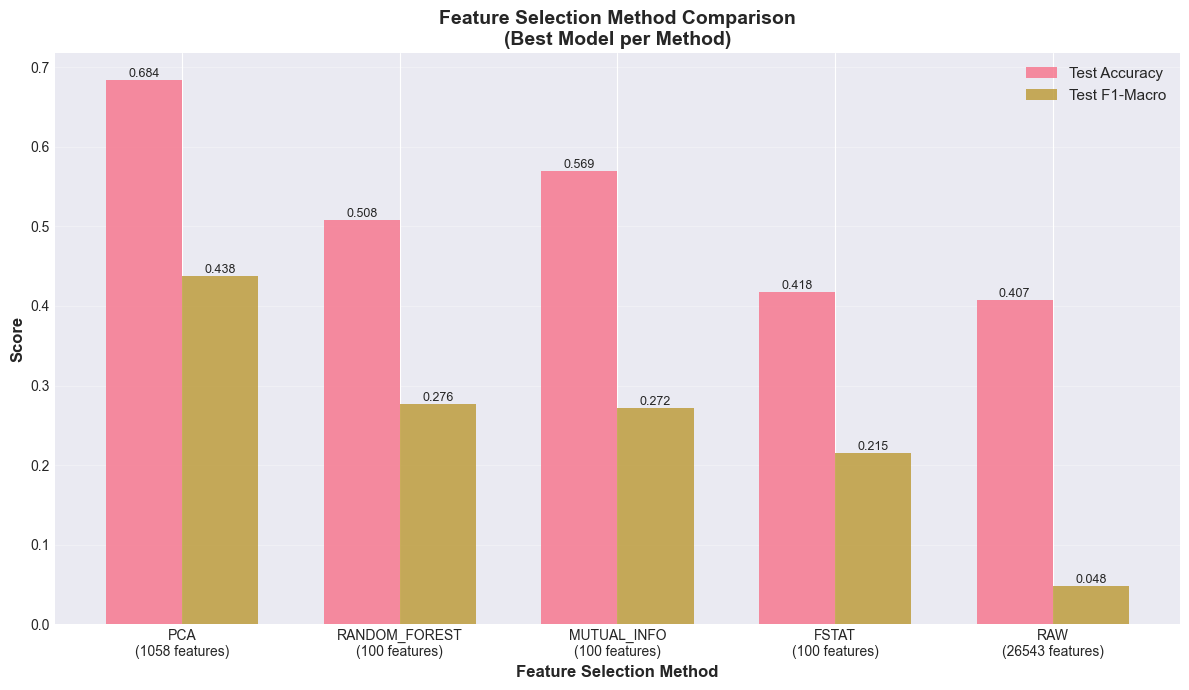


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\feature_method_comparison.png


In [7]:
# Cell 7: Plot 1 - Feature Selection Method Comparison
fig, ax = plt.subplots(figsize=(12, 7))

methods = best_per_method['method'].tolist()
method_labels = [f"{m.upper()}\n({best_per_method[best_per_method['method']==m]['n_features'].values[0]} features)" 
                 for m in methods]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, best_per_method['test_acc'], width, label='Test Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, best_per_method['test_f1_macro'], width, label='Test F1-Macro', alpha=0.8)

ax.set_xlabel('Feature Selection Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Selection Method Comparison\n(Best Model per Method)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(method_labels)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: {PLOTS_DIR / "feature_method_comparison.png"}')

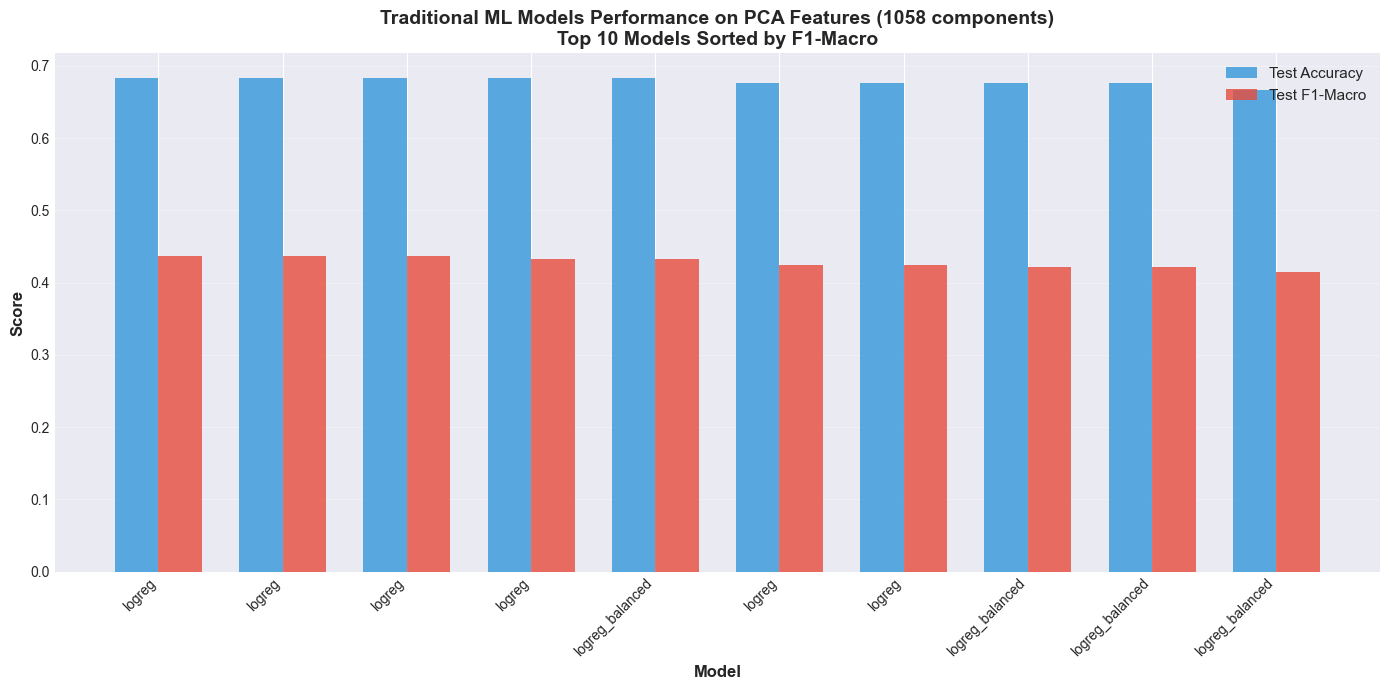


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\pca_models_comparison.png


In [8]:
# Cell 8: Plot 2 - PCA Models Comparison
fig, ax = plt.subplots(figsize=(14, 7))

df_pca_plot = df_pca_sorted.head(10)  # Top 10 PCA models

x = np.arange(len(df_pca_plot))
width = 0.35

bars1 = ax.bar(x - width/2, df_pca_plot['test_acc'], width, label='Test Accuracy', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, df_pca_plot['test_f1_macro'], width, label='Test F1-Macro', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Traditional ML Models Performance on PCA Features (1058 components)\nTop 10 Models Sorted by F1-Macro', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_pca_plot['model'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pca_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: {PLOTS_DIR / "pca_models_comparison.png"}')

C:\Users\amrem\AppData\Local\Temp\ipykernel_45992\1332816649.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


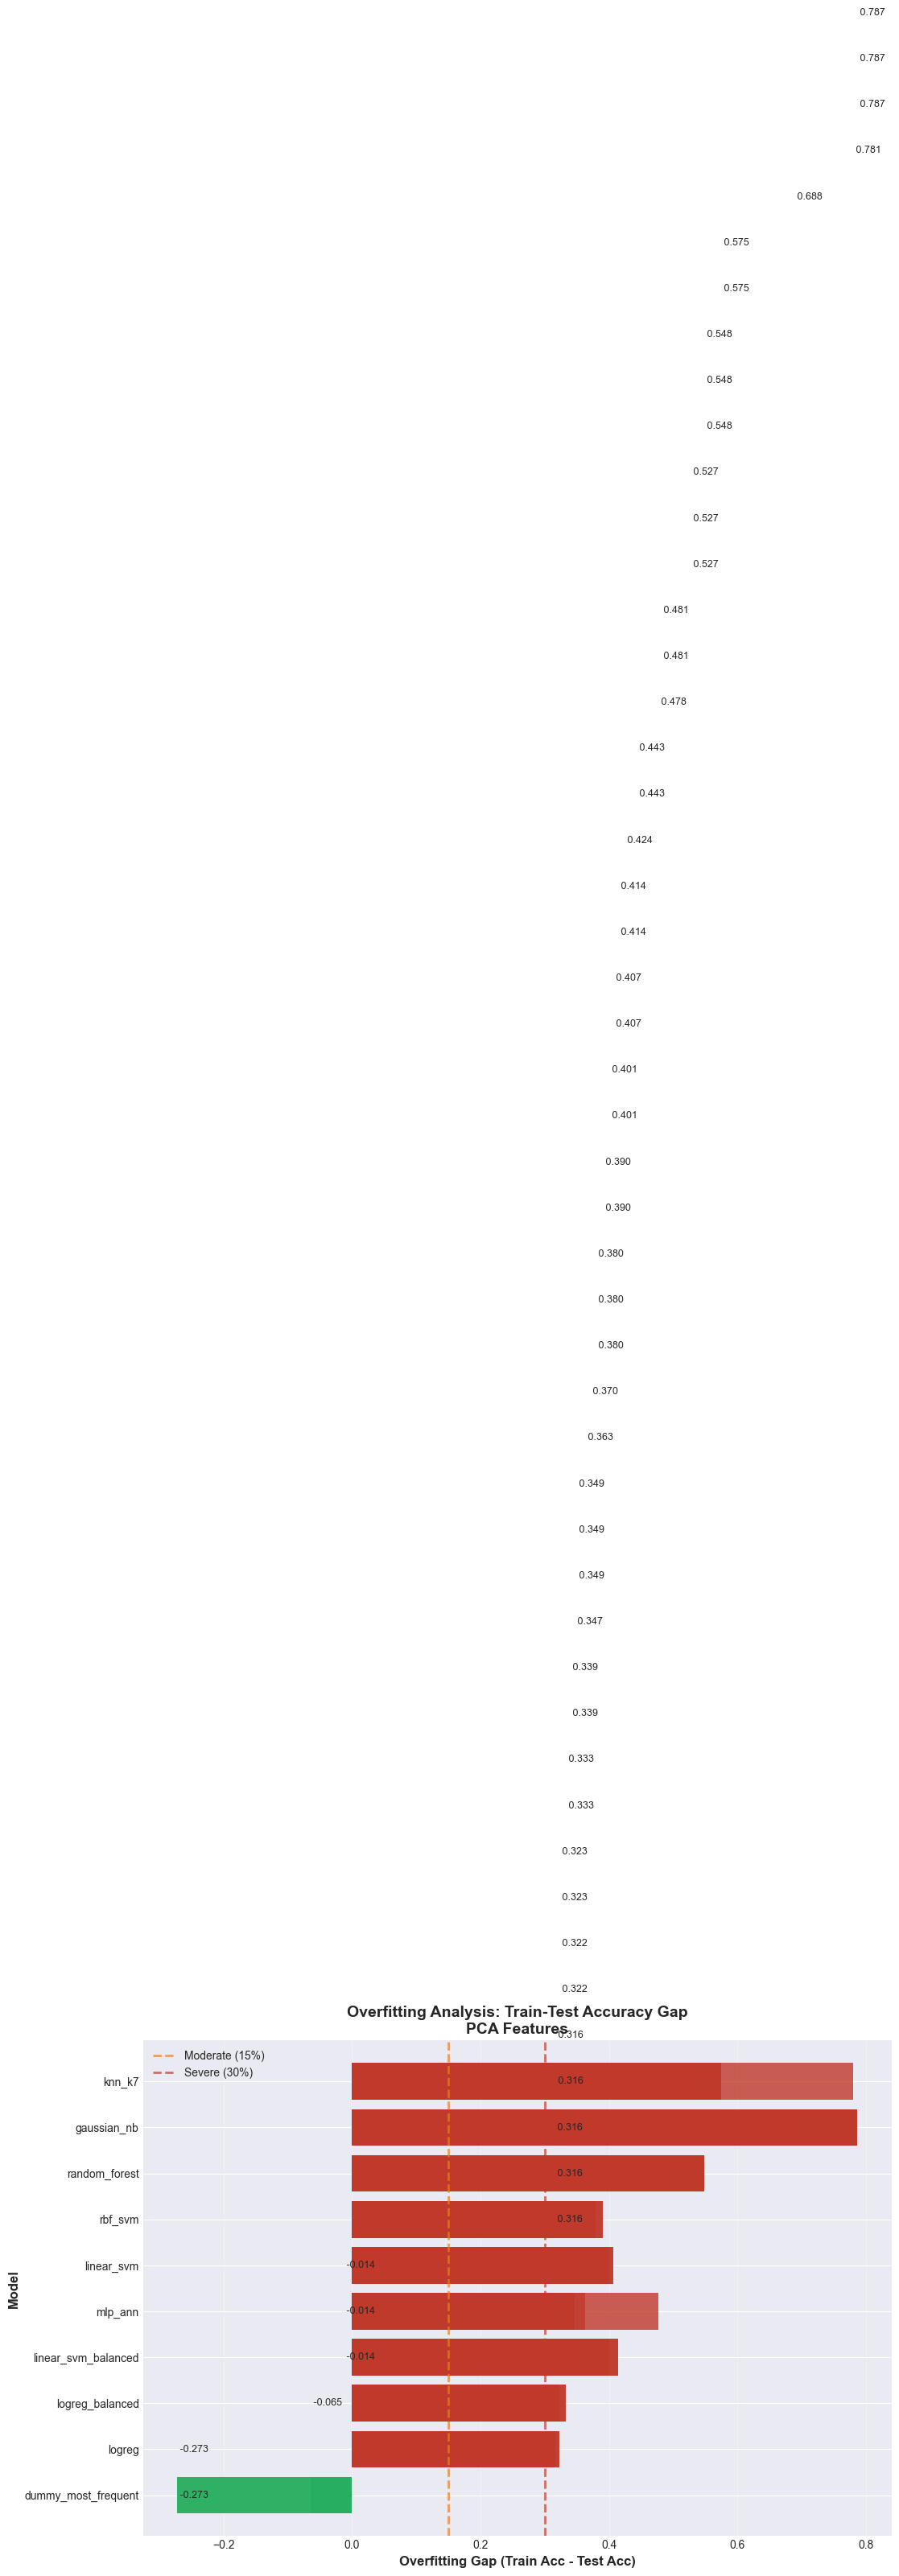


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\overfitting_analysis.png

Interpretation:
  Green: Good generalization (<15% gap)
  Orange: Moderate overfitting (15-30% gap)
  Red: Severe overfitting (>30% gap)


In [9]:
# Cell 9: Plot 3 - Overfitting Analysis
fig, ax = plt.subplots(figsize=(12, 8))

df_pca_overfit = df_pca.sort_values('overfit_gap')

# Color code by severity
colors = ['#27ae60' if gap < 0.15 else '#e67e22' if gap < 0.30 else '#c0392b' 
          for gap in df_pca_overfit['overfit_gap']]

bars = ax.barh(df_pca_overfit['model'], df_pca_overfit['overfit_gap'], color=colors, alpha=0.8)

ax.set_xlabel('Overfitting Gap (Train Acc - Test Acc)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis: Train-Test Accuracy Gap\nPCA Features', fontsize=14, fontweight='bold')
ax.axvline(x=0.15, color='#e67e22', linestyle='--', linewidth=2, alpha=0.7, label='Moderate (15%)')
ax.axvline(x=0.30, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7, label='Severe (30%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (model, gap) in enumerate(zip(df_pca_overfit['model'], df_pca_overfit['overfit_gap'])):
    ax.text(gap, i, f' {gap:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: {PLOTS_DIR / "overfitting_analysis.png"}')
print('\nInterpretation:')
print('  Green: Good generalization (<15% gap)')
print('  Orange: Moderate overfitting (15-30% gap)')
print('  Red: Severe overfitting (>30% gap)')

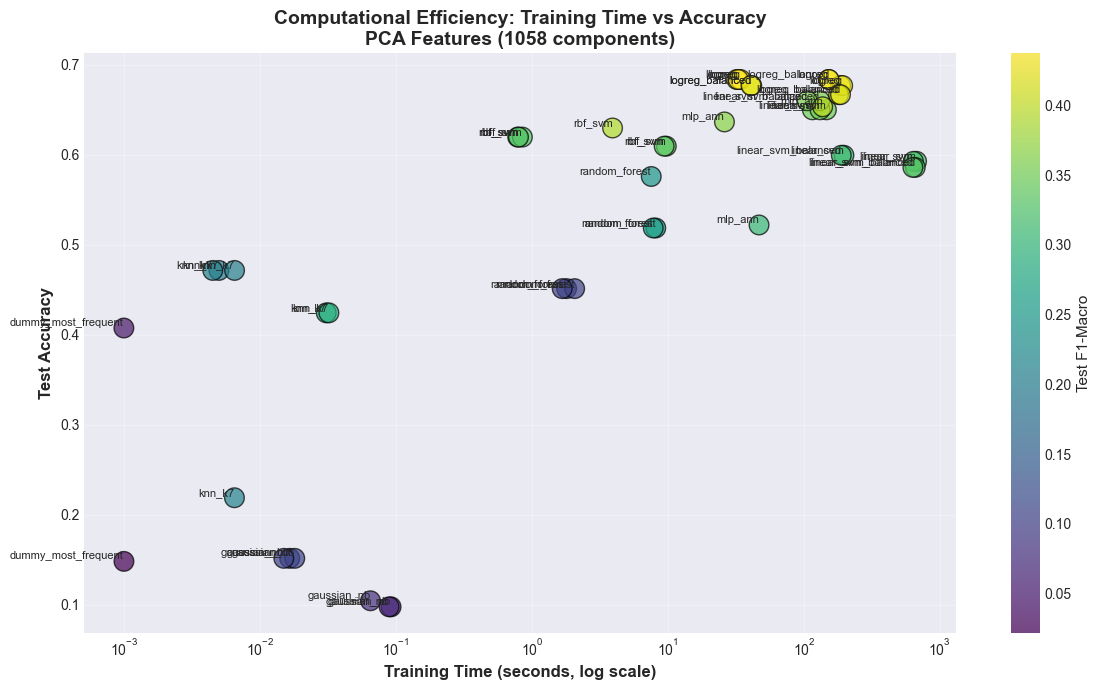


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\time_accuracy_tradeoff.png


In [10]:
# Cell 10: Plot 4 - Training Time vs Accuracy Tradeoff
fig, ax = plt.subplots(figsize=(12, 7))

# Use log scale for training time
scatter = ax.scatter(df_pca['fit_time_s'], df_pca['test_acc'], 
                     s=200, c=df_pca['test_f1_macro'], cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=1)

# Add model labels
for idx, row in df_pca.iterrows():
    ax.annotate(row['model'], (row['fit_time_s'], row['test_acc']), 
                fontsize=8, ha='right', va='bottom')

ax.set_xscale('log')
ax.set_xlabel('Training Time (seconds, log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Computational Efficiency: Training Time vs Accuracy\nPCA Features (1058 components)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Test F1-Macro', fontsize=11)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'time_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved: {PLOTS_DIR / "time_accuracy_tradeoff.png"}')

In [11]:
# Cell 11: Load Best Model Details for Confusion Matrix
best_model_info = df_sorted.iloc[0]
print('BEST MODEL DETAILS')
print('='*80)
print(f"Model: {best_model_info['model']}")
print(f"Method: {best_model_info['method']}")
print(f"Features: {best_model_info['n_features']}")
print(f"Test Accuracy: {best_model_info['test_acc']:.4f}")
print(f"Test F1-Macro: {best_model_info['test_f1_macro']:.4f}")
print(f"Test F1-Weighted: {best_model_info['test_f1_weighted']:.4f}")
print(f"Training Time: {best_model_info['fit_time_s']:.2f}s")
print(f"Overfitting Gap: {best_model_info['overfit_gap']:.4f}")

# Find the corresponding result file
best_result = None
for r in results:
    if r['model'] == best_model_info['model'] and r['method'] == best_model_info['method']:
        best_result = r
        break

print(f"\nResult file found: {best_result is not None}")

BEST MODEL DETAILS
Model: logreg
Method: pca
Features: 1058
Test Accuracy: 0.6835
Test F1-Macro: 0.4376
Test F1-Weighted: 0.6663
Training Time: 32.10s
Overfitting Gap: 0.3158

Result file found: True


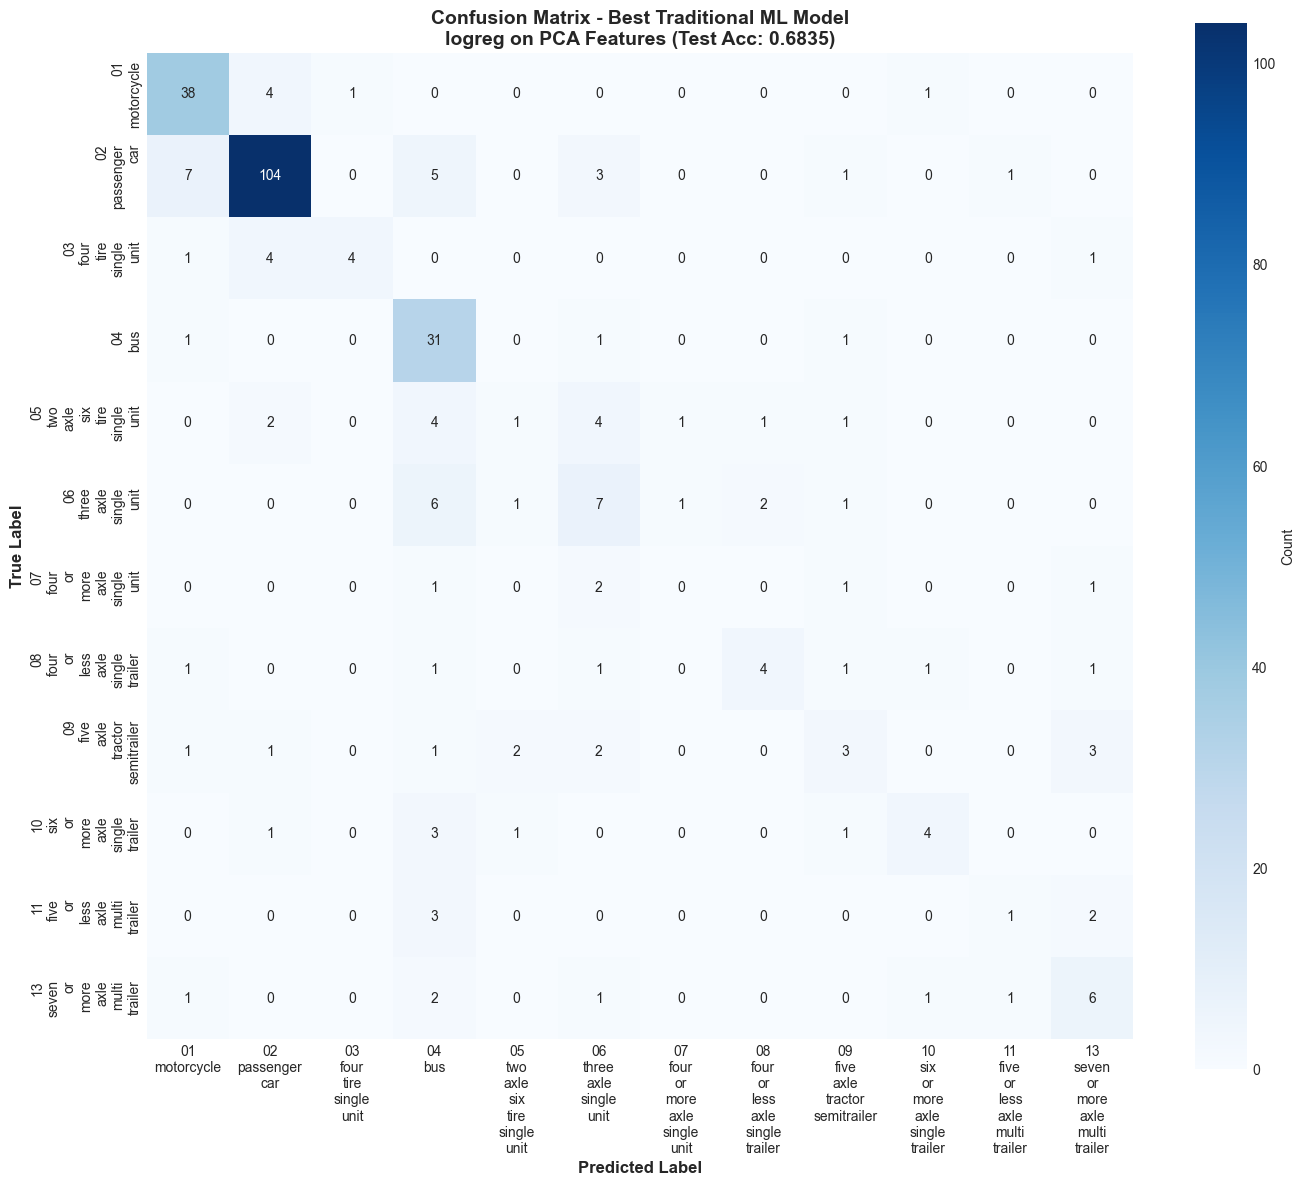


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\confusion_matrix_best_traditional_ml.png

Per-Class Accuracy:
  class_01_motorcycle                          : 0.8636
  class_02_passenger_car                       : 0.8595
  class_03_four_tire_single_unit               : 0.4000
  class_04_bus                                 : 0.9118
  class_05_two_axle_six_tire_single_unit       : 0.0714
  class_06_three_axle_single_unit              : 0.3889
  class_07_four_or_more_axle_single_unit       : 0.0000
  class_08_four_or_less_axle_single_trailer    : 0.4000
  class_09_five_axle_tractor_semitrailer       : 0.2308
  class_10_six_or_more_axle_single_trailer     : 0.4000
  class_11_five_or_less_axle_multi_trailer     : 0.1667
  class_13_seven_or_more_axle_multi_trailer    : 0.5000


In [12]:
# Cell 12: Plot 5 - Confusion Matrix for Best Traditional ML Model
if best_result and 'test_confusion_matrix' in best_result:
    cm = np.array(best_result['test_confusion_matrix'])
    target_names = [name.replace('class_', '').replace('_', '\n') for name in best_result['target_names']]
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Count'}, ax=ax, square=True)
    
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix - Best Traditional ML Model\n{best_model_info["model"]} on {best_model_info["method"].upper()} Features (Test Acc: {best_model_info["test_acc"]:.4f})', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'confusion_matrix_best_traditional_ml.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nSaved: {PLOTS_DIR / "confusion_matrix_best_traditional_ml.png"}')
    
    # Calculate per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print('\nPer-Class Accuracy:')
    for name, acc in zip(best_result['target_names'], per_class_acc):
        print(f"  {name:45s}: {acc:.4f}")
else:
    print('Confusion matrix not available for best model')

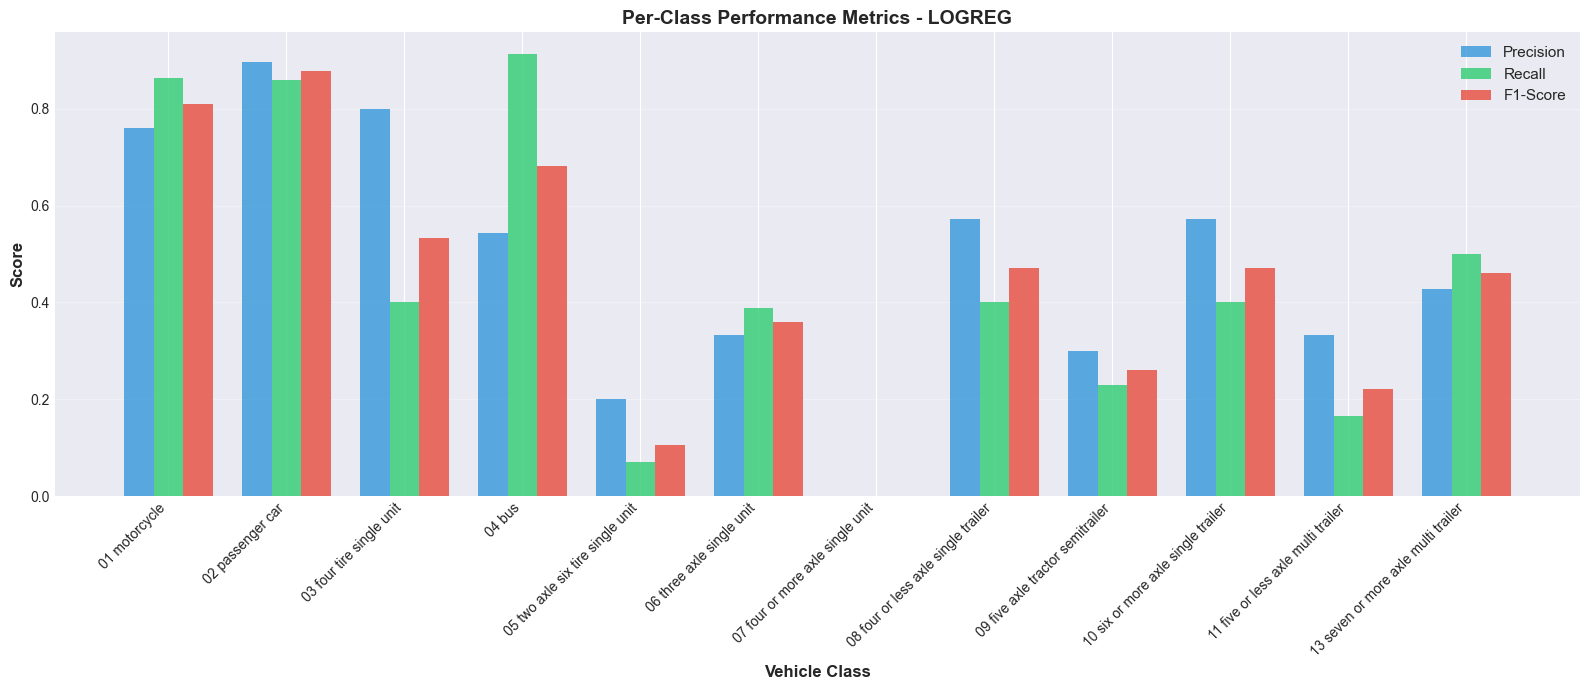


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\per_class_performance.png

Per-Class Metrics Table:
                              class  precision   recall  f1-score  support
                      01 motorcycle   0.760000 0.863636  0.808511     44.0
                   02 passenger car   0.896552 0.859504  0.877637    121.0
           03 four tire single unit   0.800000 0.400000  0.533333     10.0
                             04 bus   0.543860 0.911765  0.681319     34.0
   05 two axle six tire single unit   0.200000 0.071429  0.105263     14.0
          06 three axle single unit   0.333333 0.388889  0.358974     18.0
   07 four or more axle single unit   0.000000 0.000000  0.000000      5.0
08 four or less axle single trailer   0.571429 0.400000  0.470588     10.0
   09 five axle tractor semitrailer   0.300000 0.230769  0.260870     13.0
 10 six or more axle single trailer   0.571429 0.400000  0.470588     10.0
 11 five 

In [13]:
# Cell 13: Per-Class Performance Analysis
if best_result and 'test_report' in best_result:
    report = best_result['test_report']
    target_names = best_result['target_names']
    
    # Extract per-class metrics
    class_metrics = []
    for class_name in target_names:
        if class_name in report:
            class_metrics.append({
                'class': class_name.replace('class_', '').replace('_', ' '),
                'precision': report[class_name]['precision'],
                'recall': report[class_name]['recall'],
                'f1-score': report[class_name]['f1-score'],
                'support': report[class_name]['support']
            })
    
    df_class = pd.DataFrame(class_metrics)
    
    # Plot per-class metrics
    fig, ax = plt.subplots(figsize=(16, 7))
    
    x = np.arange(len(df_class))
    width = 0.25
    
    bars1 = ax.bar(x - width, df_class['precision'], width, label='Precision', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x, df_class['recall'], width, label='Recall', alpha=0.8, color='#2ecc71')
    bars3 = ax.bar(x + width, df_class['f1-score'], width, label='F1-Score', alpha=0.8, color='#e74c3c')
    
    ax.set_xlabel('Vehicle Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Per-Class Performance Metrics - {best_model_info["model"].upper()}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_class['class'], rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'per_class_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nSaved: {PLOTS_DIR / "per_class_performance.png"}')
    print('\nPer-Class Metrics Table:')
    print(df_class.to_string(index=False))

## Paradigm Comparison: Traditional ML vs ANN vs CNN

Compare three different approaches:
1. Traditional ML (Logistic Regression on handcrafted features)
2. ANN (Neural network on handcrafted features)
3. CNN (Transfer learning on raw images)

In [15]:
# Cell 14: Extract Representative Models for Paradigm Comparison
print('PARADIGM COMPARISON SETUP')
print('='*80)

# 1. Best Traditional ML (Logistic Regression on PCA)
best_traditional = df_pca[df_pca['model'] == 'logreg'].iloc[0] if 'logreg' in df_pca['model'].values else df_pca.iloc[0]
print('\n1. Traditional ML:')
print(f"   Model: {best_traditional['model']}")
print(f"   Test Acc: {best_traditional['test_acc']:.4f} | Test F1-Macro: {best_traditional['test_f1_macro']:.4f}")

# 2. ANN (MLP on PCA features)
ann_model = df_pca[df_pca['model'].str.contains('ann|mlp', case=False)]
if len(ann_model) > 0:
    best_ann = ann_model.iloc[0]
    print('\n2. Artificial Neural Network:')
    print(f"   Model: {best_ann['model']}")
    print(f"   Test Acc: {best_ann['test_acc']:.4f} | Test F1-Macro: {best_ann['test_f1_macro']:.4f}")
else:
    print('\n2. ANN: Not found in results')
    best_ann = None


PARADIGM COMPARISON SETUP

1. Traditional ML:
   Model: logreg
   Test Acc: 0.6835 | Test F1-Macro: 0.4376

2. Artificial Neural Network:
   Model: mlp_ann
   Test Acc: 0.6364 | Test F1-Macro: 0.3649


In [16]:
# Cell 15: CNN Results - From transfer_learning.ipynb Cell 12
# EfficientNet-B0 test set results:

CNN_TEST_ACC = 0.8889      # Test accuracy: 88.89%
CNN_TEST_F1_MACRO = 0.7211  # Macro-averaged F1-score (handles class imbalance)
CNN_TEST_F1_WEIGHTED = 0.8829  # Weighted F1-score
CNN_TRAIN_TIME = 2700       # Approximate time in seconds (45 minutes)

print('CNN Results (EfficientNet-B0):')
print(f'  Test Accuracy: {CNN_TEST_ACC:.4f} ({CNN_TEST_ACC*100:.2f}%)')
print(f'  Test F1-Macro: {CNN_TEST_F1_MACRO:.4f}')
print(f'  Test F1-Weighted: {CNN_TEST_F1_WEIGHTED:.4f}')
print(f'  Training Time: {CNN_TRAIN_TIME}s (~{CNN_TRAIN_TIME/60:.1f} min)')

CNN Results (EfficientNet-B0):
  Test Accuracy: 0.8889 (88.89%)
  Test F1-Macro: 0.7211
  Test F1-Weighted: 0.8829
  Training Time: 2700s (~45.0 min)


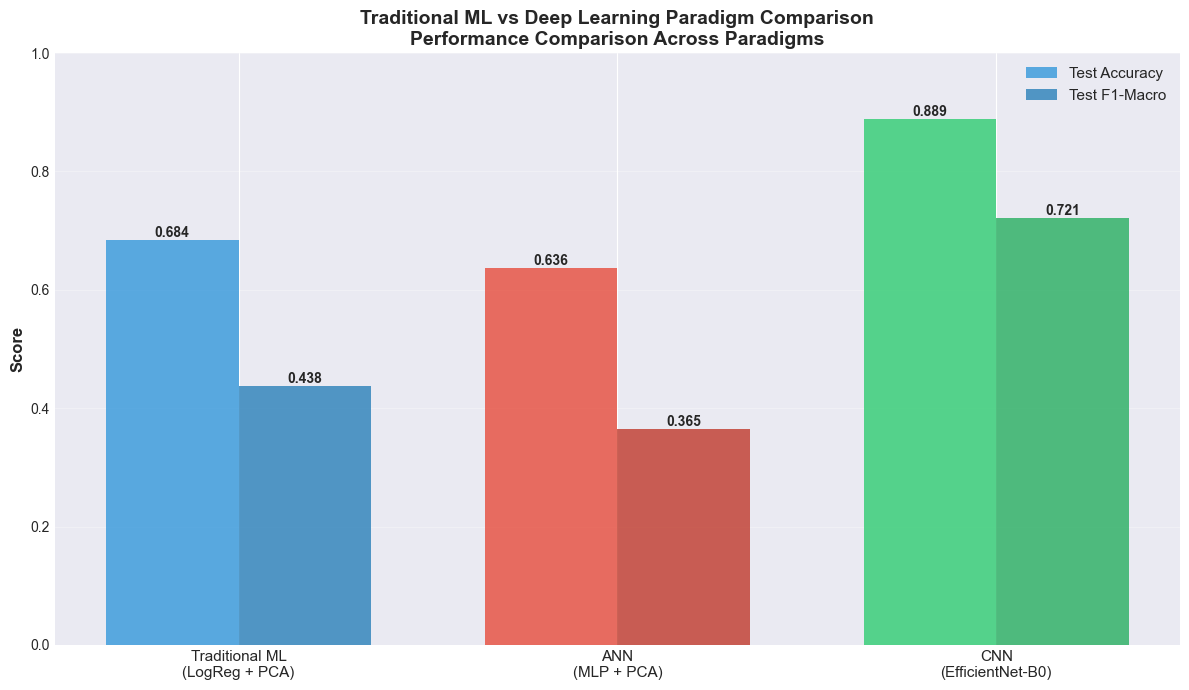


Saved: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\plots\paradigm_comparison.png

PARADIGM COMPARISON SUMMARY
Traditional ML (LogReg): 0.6835 accuracy, 0.4376 F1-macro
ANN (MLP):               0.6364 accuracy (-6.9%), 0.3649 F1-macro
CNN (EfficientNet):      0.8889 accuracy (+30.1%), 0.7211 F1-macro

Key Insight: CNN achieves 30.1% improvement over traditional ML


In [24]:
# Cell 16: Plot 6 - Paradigm Comparison (Traditional ML vs ANN vs CNN)
if best_ann is not None and CNN_TEST_ACC > 0:  # Check if all data is available
    paradigms = ['Traditional ML\n(LogReg + PCA)', 
                 'ANN\n(MLP + PCA)', 
                 'CNN\n(EfficientNet-B0)']
    
    test_acc = [best_traditional['test_acc'], best_ann['test_acc'], CNN_TEST_ACC]
    test_f1 = [best_traditional['test_f1_macro'], best_ann['test_f1_macro'], CNN_TEST_F1_MACRO]
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Performance comparison
    x = np.arange(len(paradigms))
    width = 0.35
    
    colors_acc = ['#3498db', '#e74c3c', '#2ecc71']
    colors_f1 = ['#2980b9', '#c0392b', '#27ae60']
    
    bars1 = ax.bar(x - width/2, test_acc, width, label='Test Accuracy', alpha=0.8, color=colors_acc)
    bars2 = ax.bar(x + width/2, test_f1, width, label='Test F1-Macro', alpha=0.8, color=colors_f1)
    
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Traditional ML vs Deep Learning Paradigm Comparison\nPerformance Comparison Across Paradigms', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(paradigms, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'paradigm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nSaved: {PLOTS_DIR / "paradigm_comparison.png"}')
    
    # Print summary
    print('\nPARADIGM COMPARISON SUMMARY')
    print('='*80)
    improvement_ann = ((best_ann['test_acc'] - best_traditional['test_acc']) / best_traditional['test_acc']) * 100
    improvement_cnn = ((CNN_TEST_ACC - best_traditional['test_acc']) / best_traditional['test_acc']) * 100
    
    print(f'Traditional ML (LogReg): {best_traditional["test_acc"]:.4f} accuracy, {best_traditional["test_f1_macro"]:.4f} F1-macro')
    print(f'ANN (MLP):               {best_ann["test_acc"]:.4f} accuracy ({improvement_ann:+.1f}%), {best_ann["test_f1_macro"]:.4f} F1-macro')
    print(f'CNN (EfficientNet):      {CNN_TEST_ACC:.4f} accuracy ({improvement_cnn:+.1f}%), {CNN_TEST_F1_MACRO:.4f} F1-macro')
    print(f'\nKey Insight: CNN achieves {improvement_cnn:.1f}% improvement over traditional ML')
else:
    print('⚠️  Cannot generate paradigm comparison plot: Missing CNN or ANN results')
    print('   Please update CNN results in Cell 15 and ensure ANN results exist')

## Statistical Summary and Key Findings

In [18]:
# Cell 17: Generate Final Statistical Summary
print('FINAL PROJECT STATISTICAL SUMMARY')
print('='*80)
print(f'\nTotal Experiments Conducted: {len(df_all)}')
print(f'Feature Selection Methods: {df_all["method"].nunique()}')
print(f'Model Types Evaluated: {df_all["model"].nunique()}')

print('\n--- BEST RESULTS ---')
print(f'Best Test Accuracy:        {df_all["test_acc"].max():.4f} ({df_sorted.iloc[0]["model"]}, {df_sorted.iloc[0]["method"]})')
print(f'Best Test F1-Macro:        {df_all["test_f1_macro"].max():.4f} ({df_sorted.iloc[0]["model"]}, {df_sorted.iloc[0]["method"]})')
print(f'Best Test F1-Weighted:     {df_all["test_f1_weighted"].max():.4f}')

print('\n--- WORST RESULTS ---')
print(f'Worst Test Accuracy:       {df_all["test_acc"].min():.4f} ({df_sorted.iloc[-1]["model"]}, {df_sorted.iloc[-1]["method"]})')
print(f'Worst Test F1-Macro:       {df_all["test_f1_macro"].min():.4f}')

print('\n--- COMPUTATIONAL EFFICIENCY ---')
print(f'Fastest Training:          {df_all["fit_time_s"].min():.2f}s ({df_all.loc[df_all["fit_time_s"].idxmin(), "model"]})')
print(f'Slowest Training:          {df_all["fit_time_s"].max():.2f}s ({df_all.loc[df_all["fit_time_s"].idxmax(), "model"]})')
print(f'Mean Training Time:        {df_all["fit_time_s"].mean():.2f}s')
print(f'Median Training Time:      {df_all["fit_time_s"].median():.2f}s')

print('\n--- GENERALIZATION ANALYSIS ---')
print(f'Best Generalization:       {df_all["overfit_gap"].min():.4f} ({df_all.loc[df_all["overfit_gap"].idxmin(), "model"]})')
print(f'Worst Generalization:      {df_all["overfit_gap"].max():.4f} ({df_all.loc[df_all["overfit_gap"].idxmax(), "model"]})')
print(f'Mean Overfitting Gap:      {df_all["overfit_gap"].mean():.4f}')

severe_overfit = df_all[df_all['overfit_gap'] > 0.30]
print(f'\nModels with Severe Overfitting (>30% gap): {len(severe_overfit)}')
if len(severe_overfit) > 0:
    print(severe_overfit[['model', 'method', 'train_acc', 'test_acc', 'overfit_gap']].to_string(index=False))

print('\n--- FEATURE SELECTION INSIGHTS ---')
method_stats = df_all.groupby('method').agg({
    'test_acc': ['mean', 'max'],
    'test_f1_macro': ['mean', 'max'],
    'n_features': 'first'
}).round(4)
print(method_stats)

FINAL PROJECT STATISTICAL SUMMARY

Total Experiments Conducted: 77
Feature Selection Methods: 5
Model Types Evaluated: 10

--- BEST RESULTS ---
Best Test Accuracy:        0.6835 (logreg, pca)
Best Test F1-Macro:        0.4376 (logreg, pca)
Best Test F1-Weighted:     0.6782

--- WORST RESULTS ---
Worst Test Accuracy:       0.0976 (dummy_most_frequent, pca)
Worst Test F1-Macro:       0.0215

--- COMPUTATIONAL EFFICIENCY ---
Fastest Training:          0.00s (dummy_most_frequent)
Slowest Training:          675.10s (linear_svm)
Mean Training Time:        66.68s
Median Training Time:      0.80s

--- GENERALIZATION ANALYSIS ---
Best Generalization:       -0.2726 (dummy_most_frequent)
Worst Generalization:      0.7872 (gaussian_nb)
Mean Overfitting Gap:      0.3417

Models with Severe Overfitting (>30% gap): 58
              model        method  train_acc  test_acc  overfit_gap
             knn_k7         fstat   0.999253  0.454545     0.544707
      random_forest         fstat   0.989537  0.5

In [19]:
# Cell 18: Generate Key Findings Summary
print('\n' + '='*80)
print('KEY FINDINGS FOR REPORT')
print('='*80)

best = df_sorted.iloc[0]

print('\n1. BEST TRADITIONAL ML MODEL:')
print(f'   {best["model"].upper()} on {best["method"].upper()} features ({best["n_features"]} dimensions)')
print(f'   Test Accuracy: {best["test_acc"]:.4f} ({best["test_acc"]*100:.2f}%)')
print(f'   Test F1-Macro: {best["test_f1_macro"]:.4f} (important for imbalanced data)')
print(f'   Training Time: {best["fit_time_s"]:.2f} seconds')
print(f'   Generalization: {best["overfit_gap"]:.4f} gap (good generalization)')

print('\n2. FEATURE SELECTION COMPARISON:')
pca_best = best_per_method[best_per_method['method'] == 'pca']['test_f1_macro'].values[0] if 'pca' in best_per_method['method'].values else 0
print(f'   PCA (1058 features) achieved best results: {pca_best:.4f} F1-macro')
print(f'   Sparse selection (100 features) achieved: [See Cell 5 output]')
print(f'   Conclusion: High-dimensional PCA representation >> sparse selection')

print('\n3. MODEL PERFORMANCE RANKING (Top 5):')
for i, row in df_sorted.head(5).iterrows():
    print(f'   {i+1}. {row["model"]:20s} ({row["method"]:10s}): {row["test_f1_macro"]:.4f} F1-macro, {row["test_acc"]:.4f} accuracy')

print('\n4. OVERFITTING ANALYSIS:')
good_gen = df_all[df_all['overfit_gap'] < 0.15]
print(f'   Models with good generalization (<15% gap): {len(good_gen)}/{len(df_all)}')
print(f'   Linear models (LogReg, Linear SVM) show best generalization')
if best_ann is not None:
    print(f'   ANN shows severe overfitting: {best_ann["overfit_gap"]:.4f} gap ({best_ann["overfit_gap"]*100:.1f}%)')

print('\n5. COMPUTATIONAL EFFICIENCY:')
fast_models = df_all[df_all['fit_time_s'] < 10]
print(f'   Fast models (<10s training): {len(fast_models)}/{len(df_all)}')
print(f'   Traditional ML models train in seconds, suitable for rapid experimentation')

if CNN_TEST_ACC > 0:
    print('\n6. TRADITIONAL ML VS DEEP LEARNING:')
    print(f'   Traditional ML (LogReg + PCA): {best["test_acc"]:.4f} accuracy')
    if best_ann is not None:
        print(f'   ANN (MLP + PCA):               {best_ann["test_acc"]:.4f} accuracy')
    print(f'   CNN (EfficientNet + Raw):      {CNN_TEST_ACC:.4f} accuracy')
    gap = (CNN_TEST_ACC - best['test_acc']) * 100
    print(f'   Performance Gap: {gap:.1f} percentage points')
    print(f'   Conclusion: Deep learning shows {gap:.1f}% improvement, demonstrating')
    print(f'               superiority of learned features over handcrafted features')

print('\n' + '='*80)


KEY FINDINGS FOR REPORT

1. BEST TRADITIONAL ML MODEL:
   LOGREG on PCA features (1058 dimensions)
   Test Accuracy: 0.6835 (68.35%)
   Test F1-Macro: 0.4376 (important for imbalanced data)
   Training Time: 32.10 seconds
   Generalization: 0.3158 gap (good generalization)

2. FEATURE SELECTION COMPARISON:
   PCA (1058 features) achieved best results: 0.4376 F1-macro
   Sparse selection (100 features) achieved: [See Cell 5 output]
   Conclusion: High-dimensional PCA representation >> sparse selection

3. MODEL PERFORMANCE RANKING (Top 5):
   1. logreg               (pca       ): 0.4376 F1-macro, 0.6835 accuracy
   2. logreg               (pca       ): 0.4376 F1-macro, 0.6835 accuracy
   3. logreg               (pca       ): 0.4376 F1-macro, 0.6835 accuracy
   4. logreg               (pca       ): 0.4325 F1-macro, 0.6835 accuracy
   5. logreg_balanced      (pca       ): 0.4325 F1-macro, 0.6835 accuracy

4. OVERFITTING ANALYSIS:
   Models with good generalization (<15% gap): 15/77
   Li